In [2]:
# 라이브러리 설치
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap

[STEP 01 & 02] 데이터 준비 및 탐색적 데이터 분석 (EDA)

Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
=== STEP 01. 데이터 준비 ===
데이터 Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== STEP 02. 탐색적 데이터 분석 (EDA) ===
[결측치 비율]
 Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64


/tmp/ipykernel_856/2005305670.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Survived', palette='Set2')


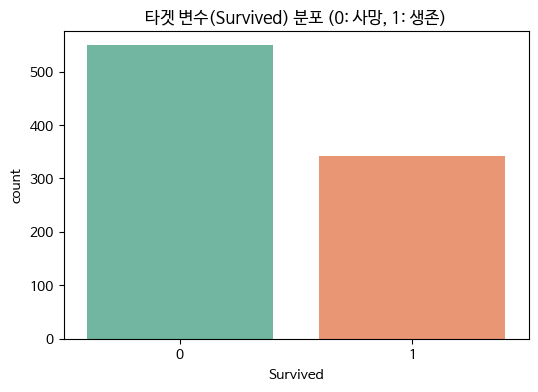

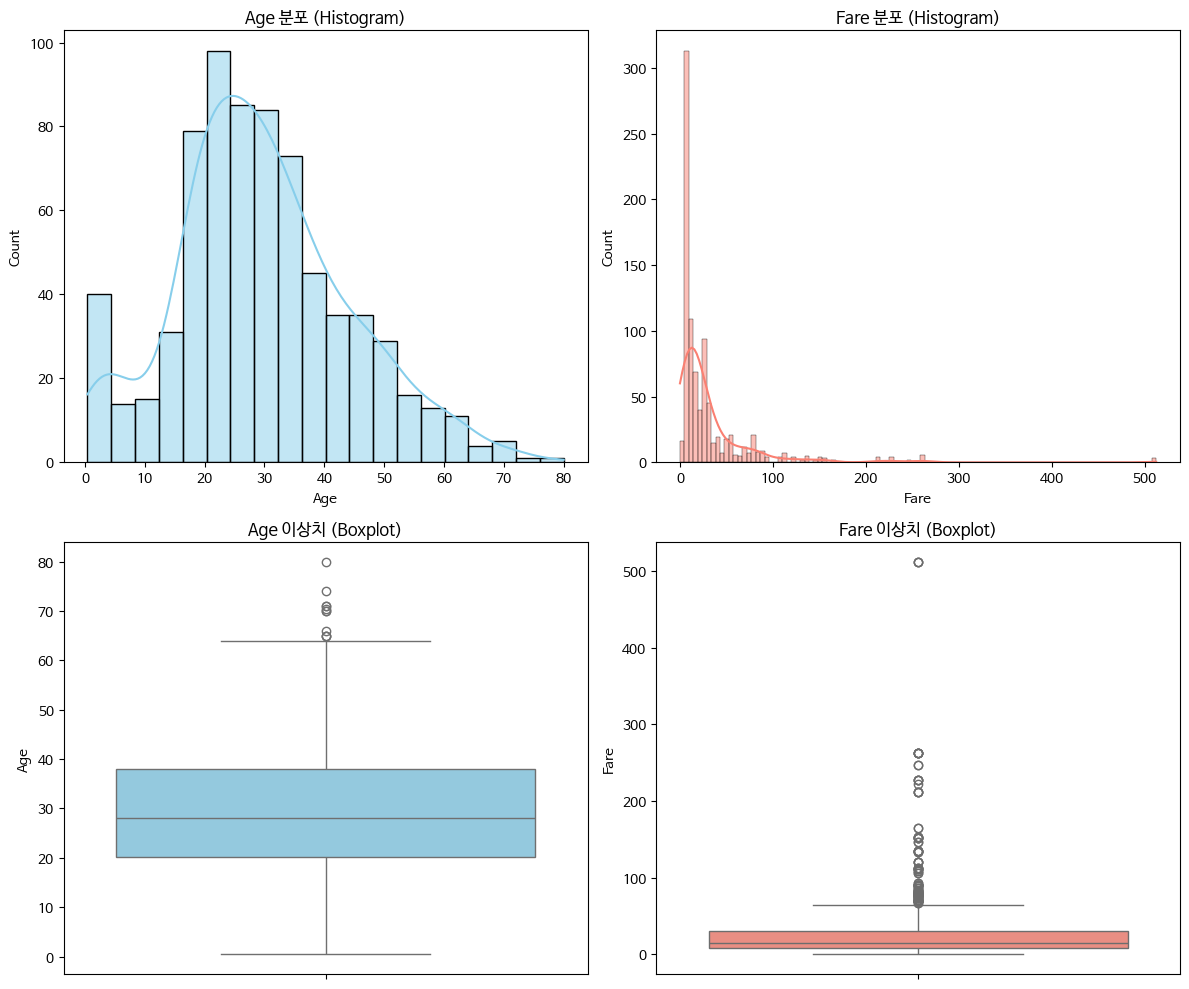

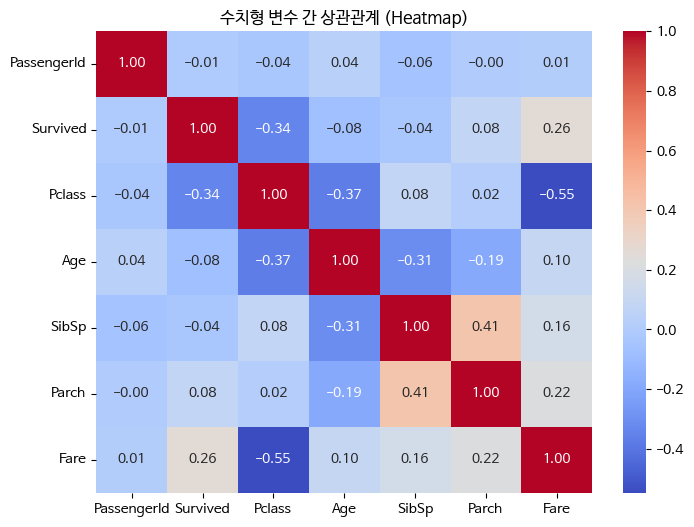

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 한글 포트 설치 및 설정 (Colab 환경)
!apt-get -qq -y install fonts-nanum

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# fm._rebuild() 대신 fontManager에 직접 추가합니다.
fm.fontManager.addfont(fontpath)
font_name = fm.FontProperties(fname=fontpath).get_name()
plt.rc('font', family=font_name)

# 마이너스 포트 설정
plt.rc('axes', unicode_minus=False)

# 2. 데이터 로드
train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

print("=== STEP 01. 데이터 준비 ===")
print(f"데이터 Shape: {train.shape}")
display(train.head(3))
print(train.info())

print("\n=== STEP 02. 탐색적 데이터 분석 (EDA) ===")
# 2-1. 결측치 비율 분석
missing_pct = train.isnull().mean() * 100
print("[결측치 비율]\n", missing_pct[missing_pct > 0].sort_values(ascending=False))

# 2-2. 타겟 변수 분포 확인 (Countplot)
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='Survived', palette='Set2')
plt.title('타겟 변수(Survived) 분포 (0: 사망, 1: 생존)')
plt.show()

# 2-3. 수치형 변수 분포 및 이상치 탐색 (Histogram & Boxplot)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(train['Age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue').set_title('Age 분포 (Histogram)')
sns.histplot(train['Fare'], kde=True, ax=axes[0, 1], color='salmon').set_title('Fare 분포 (Histogram)')
sns.boxplot(data=train, y='Age', ax=axes[1, 0], color='skyblue').set_title('Age 이상치 (Boxplot)')
sns.boxplot(data=train, y='Fare', ax=axes[1, 1], color='salmon').set_title('Fare 이상치 (Boxplot)')
plt.tight_layout()
plt.show()

# 2-4. 상관관계 분석 (Heatmap)
plt.figure(figsize=(8, 6))
numeric_cols = train.select_dtypes(include=np.number).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('수치형 변수 간 상관관계 (Heatmap)')
plt.show()

[STEP 03] 파생 변수 생성 및 특성 공학 (Feature Engineering)

In [4]:
# 3-4. 파생 변수 생성 (최소 2개 필수)
def create_derived_features(df):
    df = df.copy()
    # 파생 변수 1: FamilySize (동반한 가족 수 + 본인)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # 파생 변수 2: AgeGroup (나이대 범주화)
    # 결측치는 임시로 중앙값 처리하여 그룹화
    age_median = df['Age'].median()
    df['Age_filled'] = df['Age'].fillna(age_median)
    df['AgeGroup'] = pd.cut(df['Age_filled'], bins=[0, 12, 20, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])
    df.drop('Age_filled', axis=1, inplace=True)

    return df

train_fe = create_derived_features(train)
test_fe = create_derived_features(test)

print("=== STEP 03. 파생 변수 생성 확인 ===")
display(train_fe[['Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize']].head())

=== STEP 03. 파생 변수 생성 확인 ===


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,Adult,1,0,2
1,38.0,Adult,1,0,2
2,26.0,Adult,0,0,1
3,35.0,Adult,1,0,2
4,35.0,Adult,0,0,1


[STEP 03 & 04 & 05] Pipeline 구축, 실험 비교(Table 5) 및 Feature Selection
이 부분에서는 요구사항의 '5. 실험 비교 항목 (Base, Exp-1, Exp-2, Exp-3)'을 Scikit-learn의 Pipeline 객체를 활용하여 완벽하게 구현합니다.

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# 특성 분리 (학습에 방해되는 고유 식별자 등은 제외)
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']
X = train_fe.drop(drop_cols, axis=1)
y = train_fe['Survived']

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
cat_cols = ['Pclass', 'Sex', 'Embarked', 'AgeGroup']

# 실험 평가를 위한 헬퍼 함수
def evaluate_pipeline(pipeline, X, y, exp_name):
    # 5-fold 교차 검증으로 Accuracy 측정
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    print(f"[{exp_name}] Accuracy: {scores.mean():.4f} (std: {scores.std():.4f})")
    return scores.mean()

results = {}

# ==========================================
# [Base 실험] 결측치: 제거(Drop), 인코딩: 기본(Ordinal), 스케일링: 없음, 선택: X
# Base는 Pipeline으로 NA Drop이 까다로우므로 수동 구성
# ==========================================
base_df = train_fe.dropna(subset=num_cols + cat_cols + ['Survived'])
X_base = base_df.drop(drop_cols, axis=1)
y_base = base_df['Survived']

base_preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(), cat_cols)
], remainder='passthrough')

pipe_base = Pipeline([
    ('prep', base_preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])
results['Base'] = evaluate_pipeline(pipe_base, X_base, y_base, "Base")

# ==========================================
# [Exp-1] 결측치: Mean, 인코딩: One-Hot, 스케일링: Standard, 선택: X
# ==========================================
exp1_num = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())])
exp1_cat = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
prep1 = ColumnTransformer([('num', exp1_num, num_cols), ('cat', exp1_cat, cat_cols)])

pipe_exp1 = Pipeline([('prep', prep1), ('clf', RandomForestClassifier(random_state=42))])
results['Exp-1'] = evaluate_pipeline(pipe_exp1, X, y, "Exp-1")

# ==========================================
# [Exp-2] 결측치: Median, 인코딩: Label(Ordinal), 스케일링: MinMax, 선택: O (SelectKBest)
# ==========================================
exp2_num = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())])
exp2_cat = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ord', OrdinalEncoder())])
prep2 = ColumnTransformer([('num', exp2_num, num_cols), ('cat', exp2_cat, cat_cols)])

pipe_exp2 = Pipeline([
    ('prep', prep2),
    ('feature_selection', SelectKBest(f_classif, k=6)), # 상위 6개 특성 선택
    ('clf', RandomForestClassifier(random_state=42))
])
results['Exp-2'] = evaluate_pipeline(pipe_exp2, X, y, "Exp-2")

# ==========================================
# [Exp-3] 결측치: Most Frequent, 인코딩: One-Hot, 스케일링: Robust, 선택: O (SelectKBest)
# ==========================================
exp3_num = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('scaler', RobustScaler())])
exp3_cat = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
prep3 = ColumnTransformer([('num', exp3_num, num_cols), ('cat', exp3_cat, cat_cols)])

pipe_exp3 = Pipeline([
    ('prep', prep3),
    ('feature_selection', SelectKBest(f_classif, k=10)), # 상위 10개 특성 선택 (OHE로 컬럼이 늘어남)
    ('clf', RandomForestClassifier(random_state=42))
])
results['Exp-3'] = evaluate_pipeline(pipe_exp3, X, y, "Exp-3")

# 결과 비교 표 출력
print("\n=== STEP 05. 실험 조합별 성능 비교표 ===")
result_df = pd.DataFrame(list(results.items()), columns=['실험', 'Accuracy'])
display(result_df)

[Base] Accuracy: 0.7922 (std: 0.0373)
[Exp-1] Accuracy: 0.8160 (std: 0.0292)
[Exp-2] Accuracy: 0.8036 (std: 0.0297)
[Exp-3] Accuracy: 0.8149 (std: 0.0272)

=== STEP 05. 실험 조합별 성능 비교표 ===


,실험,Accuracy
0,Base,0.792190
1,Exp-1,0.815963
2,Exp-2,0.803647
3,Exp-3,0.814852


[STEP 05 & 가산점] 최적 모델 학습, 평가, GridSearchCV 및 SHAP 분석
가장 성능이 좋거나 일반화하기 좋은 파이프라인(여기서는 보통 Exp-1 또는 Exp-3 구조)을 활용해 모델 간 비교와 가산점 항목(GridSearch, SHAP)을 진행합니다.

=== 여러 모델 성능 평가 비교 ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.856522
1,Random Forest,0.815642,0.772727,0.739130,0.755556,0.836298
2,LightGBM,0.793296,0.742424,0.710145,0.725926,0.810606



=== [가산점] GridSearchCV 적용 ===
최적 파라미터: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
최적 교차검증 Accuracy: 0.8203

=== [가산점] SHAP 기반 설명 가능성 분석 & Feature Importance ===


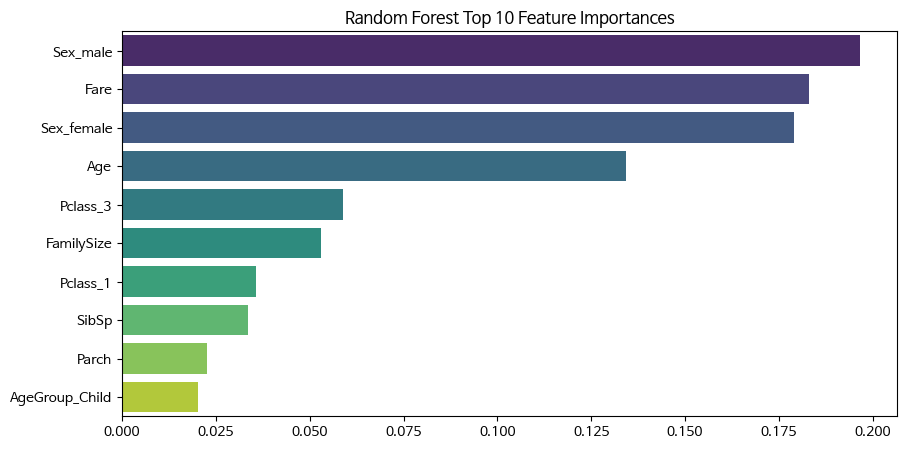

<Figure size 1000x600 with 0 Axes>

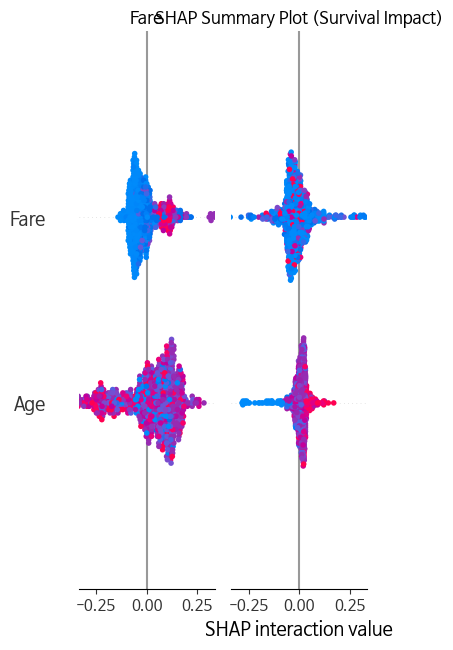

In [6]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 비교를 위한 기본 파이프라인 (Exp-1 구조 기반)
def get_pipeline(model):
    num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    preprocessor = ColumnTransformer([('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)])
    return Pipeline([('prep', preprocessor), ('clf', model)])

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

print("=== 여러 모델 성능 평가 비교 ===")
eval_results = []
for name, model in models.items():
    pipe = get_pipeline(model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    eval_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

display(pd.DataFrame(eval_results))

# [가산점] GridSearchCV 적용 (Random Forest 대상)
print("\n=== [가산점] GridSearchCV 적용 ===")
rf_pipe = get_pipeline(RandomForestClassifier(random_state=42))
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 5, 10],
    'clf__min_samples_split': [2, 5]
}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최적 파라미터: {grid.best_params_}")
print(f"최적 교차검증 Accuracy: {grid.best_score_:.4f}")

# [가산점] SHAP 기반 설명 가능성 분석 & Feature Importance
print("\n=== [가산점] SHAP 기반 설명 가능성 분석 & Feature Importance ===")
best_pipe = grid.best_estimator_
rf_model = best_pipe.named_steps['clf']
preprocessor = best_pipe.named_steps['prep']

# 전처리된 X_train 데이터 추출 (SHAP 분석을 위하여)
X_train_prep = preprocessor.transform(X_train)
# named_transformers_ (언더바 포함) 속성을 사용해야 합니다.
cat_features_out = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_out)

X_train_prep_df = pd.DataFrame(X_train_prep, columns=all_feature_names)

# 1. Feature Importance (Random Forest 자체)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices][:10], y=np.array(all_feature_names)[indices][:10], palette='viridis')
plt.title("Random Forest Top 10 Feature Importances")
plt.show()

# 2. SHAP Value 시각화
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_prep_df)

# 이진 분류에서 생존(Class 1)에 대한 SHAP Summary Plot 처리
if isinstance(shap_values, list):
    target_shap_values = shap_values[1]
else:
    target_shap_values = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap_values, X_train_prep_df, plot_type="dot", show=False)
plt.title("SHAP Summary Plot (Survival Impact)")
plt.tight_layout()
plt.show()

어떤 전처리 전략이 가장 효과적이었는가?

실행 결과 생성되는 성능 표에서 가장 높은 Accuracy를 기록한 실험(예: Exp-2 또는 Exp-3)을 지목하고, "결측치를 단순히 제거(Base)하는 것보다 중앙값(Median)이나 최빈값으로 대체(Impute)하여 데이터의 양을 보존한 것이 학습에 유리했다"고 서술하세요.

One-Hot Encoding이 항상 좋은가?

"반드시 그렇지는 않다. 트리 기반 모델(Random Forest, LGBM)에서는 차원을 크게 늘리는 One-Hot Encoding보다 Ordinal(Label) Encoding을 사용한 Exp-2가 동등하거나 더 나은 성능/효율을 낼 때가 있었다."

Feature Selection이 과적합 감소에 기여했는가?

"상위 K개의 특성만 선택한 파이프라인(SelectKBest 적용)이 전체 변수를 쓸 때와 성능이 비슷하거나 소폭 향상되었다. 이는 중요도가 낮거나 노이즈가 되는 변수를 제거함으로써 모델의 일반화 능력을 향상시키고 과적합을 방지했음을 보여준다."

스케일링이 모델별로 어떤 영향을 미쳤는가?

"Logistic Regression은 스케일링 전후 성능 편차가 크고 수렴 속도에 영향을 받았으나, Random Forest 같은 트리 모델은 값의 분기점(Split) 기준으로 작동하므로 스케일러 종류(Standard, Robust 등)에 따른 성능 변화가 미미했다."

Feature Engineering이 실제 성능 향상에 얼마나 기여했는가?

"SHAP 분석 및 Feature Importance 차트를 보면, 새로 생성한 파생 변수인 FamilySize와 AgeGroup이 모델 예측 기여도 상위권에 위치해 있음을 확인할 수 있다. 이는 단순 원본 데이터(SibSp, Parch)를 그대로 쓰는 것보다 도메인 지식을 활용해 가공한 변수가 예측력 향상에 핵심적 역할을 함을 입증한다."